In [9]:
# DATA CLEANING & PREPROCESSING - CLINICAL TRIAL DATASET

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

# STEP 1: Load the Datasets

patient_df = pd.read_csv("Patient_data.csv")
treatment_df = pd.read_csv("Treatment_data.csv")
hospital_df = pd.read_csv("Hospital_data.csv")

# Store all datasets in a dictionary
datasets = {
    "Patient": patient_df,
    "Treatment": treatment_df,
    "Hospital": hospital_df
}

# STEP 2: Dataset Information

for name, df in datasets.items():

    print("\nShape:")
    print(df.shape)

    print("\nData Types:")
    print(df.dtypes)

    print("\nFirst Five Rows:")
    print(df.head())

# STEP 3: Missing Value Detection

for name, df in datasets.items():

    print(df.isnull().sum())

    print("\nMissing Percentage")

    missing_percent = (df.isnull().sum()/len(df))*100

    print(missing_percent)

# STEP 4: Missing Value Treatment

for name, df in datasets.items():

    # Numerical Columns
    numeric_cols = df.select_dtypes(include=['int64','float64']).columns

    for col in numeric_cols:
        df[col].fillna(df[col].median(), inplace=True)

    # Categorical Columns
    categorical_cols = df.select_dtypes(include='object').columns

    for col in categorical_cols:
        df[col].fillna(df[col].mode()[0], inplace=True)

# STEP 5: Duplicate Removal

for name, df in datasets.items():

    duplicate_count = df.duplicated().sum()

    print(f"\n{name} Duplicate Records Before Removal : {duplicate_count}")

    df.drop_duplicates(inplace=True)

    print(f"{name} Shape After Removing Duplicates : {df.shape}")

# STEP 6: String Cleaning

for name, df in datasets.items():

    string_cols = df.select_dtypes(include='object').columns

    for col in string_cols:

        df[col] = (
            df[col]
            .astype(str)
            .str.strip()              # Remove leading/trailing spaces
            .str.replace(r'\s+', ' ', regex=True)   # Remove extra spaces
            .str.title()              # Standardize text
        )

print("\nString Cleaning Completed.")

# STEP 7: Data Type Conversion

# ---------- Patient Dataset ----------

if 'Date_of_Birth' in patient_df.columns:
    patient_df['Date_of_Birth'] = pd.to_datetime(
        patient_df['Date_of_Birth'],
        errors='coerce'
    )

if 'Age' in patient_df.columns:
    patient_df['Age'] = patient_df['Age'].astype('Int64')

# ---------- Treatment Dataset ----------

date_columns = ['Treatment_Date','Start_Date','End_Date']

for col in date_columns:

    if col in treatment_df.columns:
        treatment_df[col] = pd.to_datetime(
            treatment_df[col],
            errors='coerce'
        )

# ---------- Hospital Dataset ----------

if 'Established_Year' in hospital_df.columns:
    hospital_df['Established_Year'] = hospital_df['Established_Year'].astype('Int64')


# STEP 8: Verify Changes


for name, df in datasets.items():


    print("\nMissing Values")
    print(df.isnull().sum())

    print("\nDuplicates")
    print(df.duplicated().sum())

    print("\nData Types")
    print(df.dtypes)

# STEP 9: Save Cleaned Files

patient_df.to_csv("Patient_data_cleaned.csv", index=False)
treatment_df.to_csv("Treatment_data_cleaned.csv", index=False)
hospital_df.to_csv("Hospital_data_cleaned.csv", index=False)

print("\nCleaned datasets have been saved successfully!")


Shape:
(500, 7)

Data Types:
Patient_ID     object
Age             int64
Gender         object
Weight_kg     float64
Height_cm       int64
BMI           float64
Disease        object
dtype: object

First Five Rows:
  Patient_ID  Age  Gender  Weight_kg  Height_cm   BMI      Disease
0      P0001   58    Male       51.1        167  18.3     Diabetes
1      P0002   44    Male       57.1        187  16.3    Arthritis
2      P0003   47    Male       74.5        174  24.6  Lung Cancer
3      P0004   40    Male       56.5        167  20.3    Arthritis
4      P0005   63  Female       62.3        181  19.0     COVID-19

Shape:
(500, 13)

Data Types:
Patient_ID          object
Trial_ID            object
Treatment_Group     object
Dose_mg              int64
Blood_Pressure       int64
Heart_Rate           int64
Cholesterol        float64
Glucose            float64
Adverse_Event       object
Severity            object
Efficacy_Score     float64
Outcome             object
Cost_USD           float64


/tmp/ipykernel_618/3564236277.py:57: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_618/3564236277.py:63: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

# Outliers Detection and Treatment

In [15]:
# OUTLIER DETECTION & CAPPING USING IQR METHOD

# STEP 1: Load the Datasets

patient_df = pd.read_csv("Patient_data.csv")
treatment_df = pd.read_csv("Treatment_data.csv")
hospital_df = pd.read_csv("Hospital_data.csv")

# STEP 2: Function for Outlier Detection and Capping

def cap_outliers(df):

    # Copy dataframe
    capped_df = df.copy()

    # Summary list
    summary = []

    # Select only numeric columns
    numeric_columns = df.select_dtypes(include=np.number).columns

    for column in numeric_columns:

        # Calculate Quartiles
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)

        # Calculate IQR
        IQR = Q3 - Q1

        # Calculate Lower and Upper Limits
        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR

        # Count Outliers Before Capping
        outliers_before = ((df[column] < lower_limit) |
                           (df[column] > upper_limit)).sum()

        # Cap the Outliers
        capped_df[column] = np.where(
            capped_df[column] < lower_limit,
            lower_limit,
            capped_df[column]
        )

        capped_df[column] = np.where(
            capped_df[column] > upper_limit,
            upper_limit,
            capped_df[column]
        )

        # Count Outliers After Capping
        outliers_after = ((capped_df[column] < lower_limit) |
                          (capped_df[column] > upper_limit)).sum()

        # Store Summary
        summary.append({
            "Column": column,
            "Q1": Q1,
            "Q3": Q3,
            "IQR": IQR,
            "Lower Limit": lower_limit,
            "Upper Limit": upper_limit,
            "Outliers Before": outliers_before,
            "Outliers After": outliers_after
        })

    summary_df = pd.DataFrame(summary)

    return capped_df, summary_df

# STEP 3: Apply Function to All Datasets

patient_capped, patient_summary = cap_outliers(patient_df)

treatment_capped, treatment_summary = cap_outliers(treatment_df)

hospital_capped, hospital_summary = cap_outliers(hospital_df)

# STEP 4: Display Summary

print("Patient Dataset")
print(patient_summary)

print("\nTreatment Dataset")
print(treatment_summary)

print("\nHospital Dataset")
print(hospital_summary)

# STEP 5: Save Capped Datasets

patient_capped.to_csv("Patient_Capped.csv", index=False)
treatment_capped.to_csv("Treatment_Capped.csv", index=False)
hospital_capped.to_csv("Hospital_Capped.csv", index=False)

print("\nOutlier capping completed successfully!")

Patient Dataset
      Column      Q1       Q3     IQR  Lower Limit  Upper Limit  \
0        Age   34.00   64.250  30.250     -11.3750     109.6250   
1  Weight_kg   59.30   85.100  25.800      20.6000     123.8000   
2  Height_cm  158.75  180.000  21.250     126.8750     211.8750   
3        BMI   20.60   29.925   9.325       6.6125      43.9125   

   Outliers Before  Outliers After  
0                0               0  
1                0               0  
2                0               0  
3                0               0  

Treatment Dataset
           Column         Q1        Q3        IQR  Lower Limit  Upper Limit  \
0         Dose_mg     0.0000   150.000   150.0000   -225.00000    375.00000   
1  Blood_Pressure   122.0000   153.000    31.0000     75.50000    199.50000   
2      Heart_Rate    72.0000    97.000    25.0000     34.50000    134.50000   
3     Cholesterol   176.8250   243.100    66.2750     77.41250    342.51250   
4         Glucose   106.0250   180.075    74.0500

# Exploratory Data Analysis (EDA)

### 1. UNIVARIATE ANALYSIS

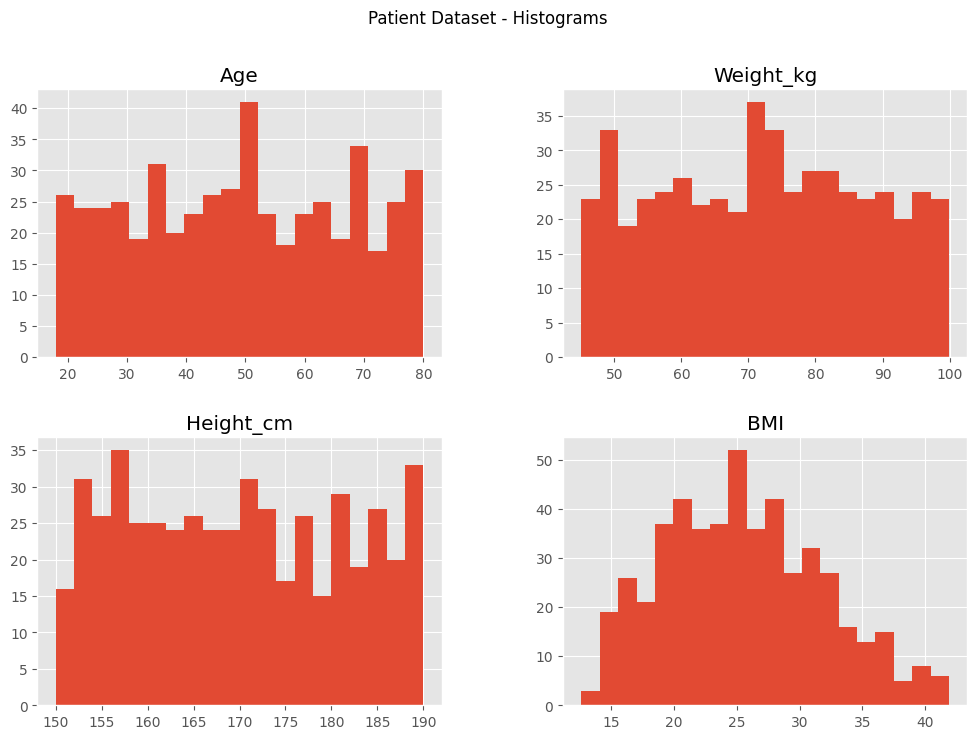

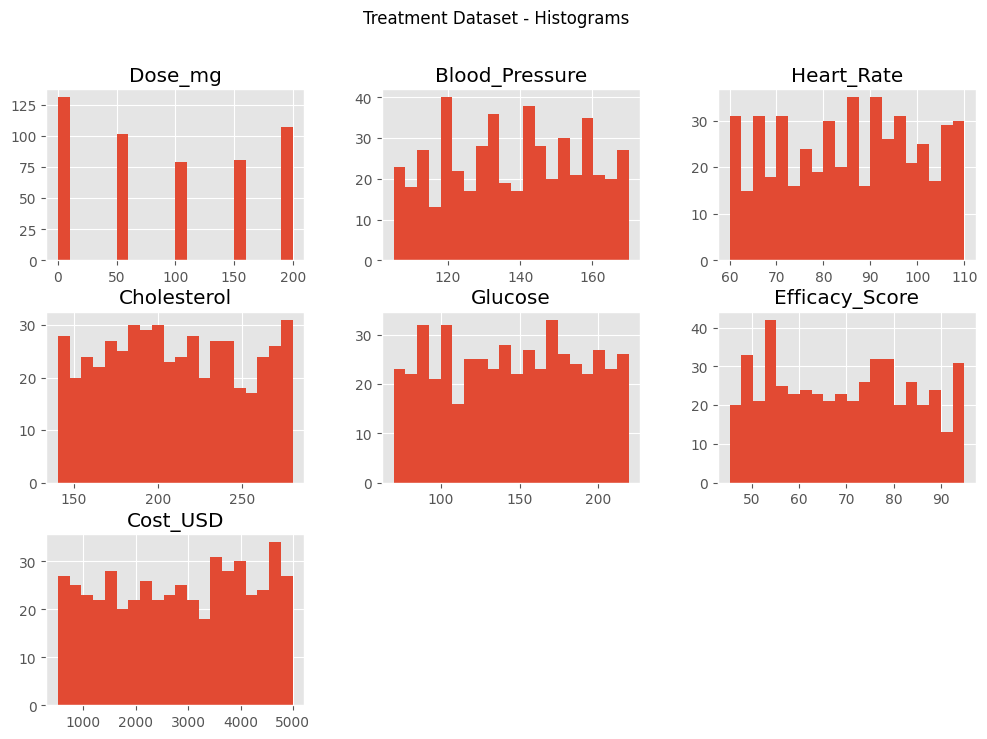

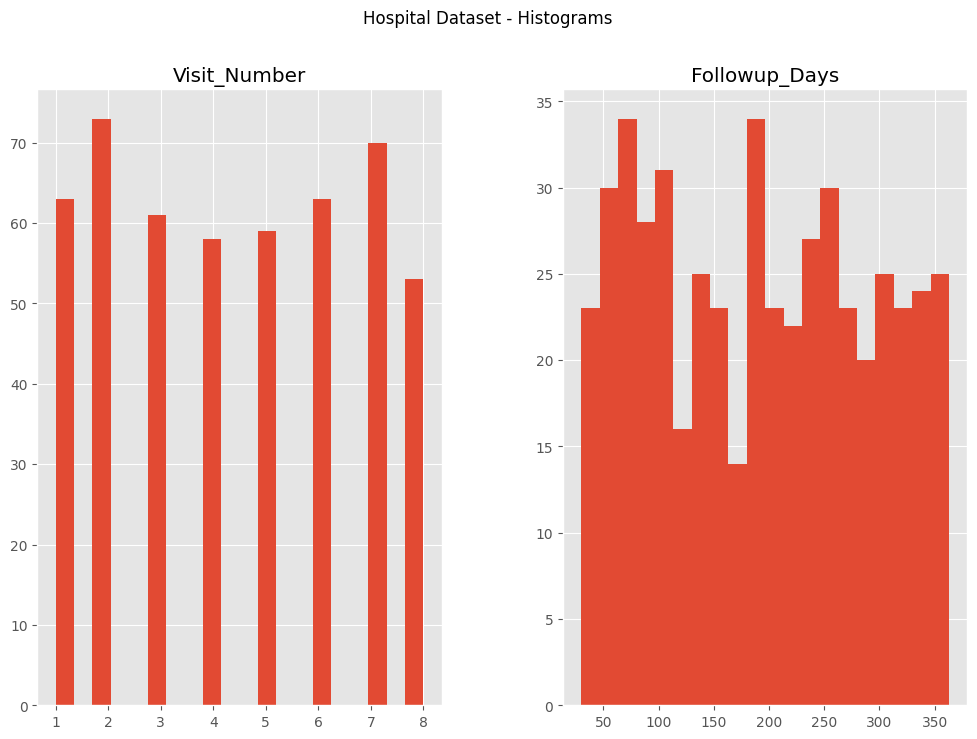

In [19]:
# 1. Histograms for Numeric Variables

# Patient Dataset

patient_df.hist(figsize=(12,8), bins=20)

plt.suptitle("Patient Dataset - Histograms")
plt.show()

# Treatment Dataset

treatment_df.hist(figsize=(12,8), bins=20)

plt.suptitle("Treatment Dataset - Histograms")
plt.show()

# Hospital Dataset

hospital_df.hist(figsize=(12,8), bins=20)

plt.suptitle("Hospital Dataset - Histograms")
plt.show()



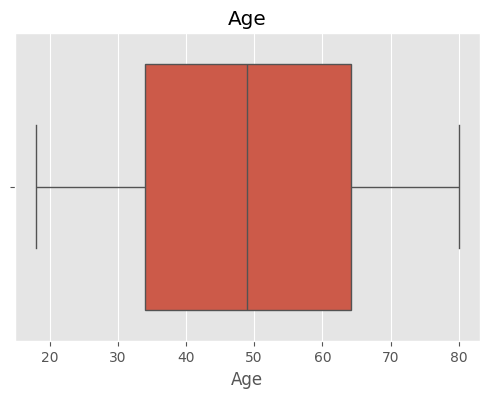

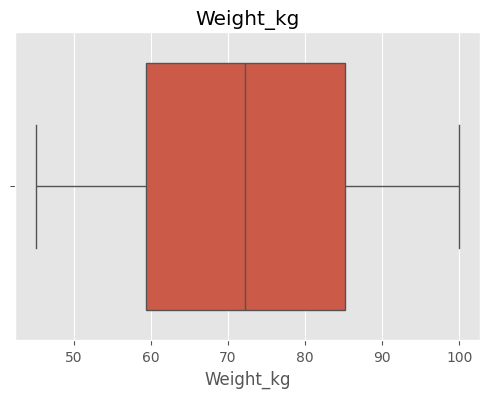

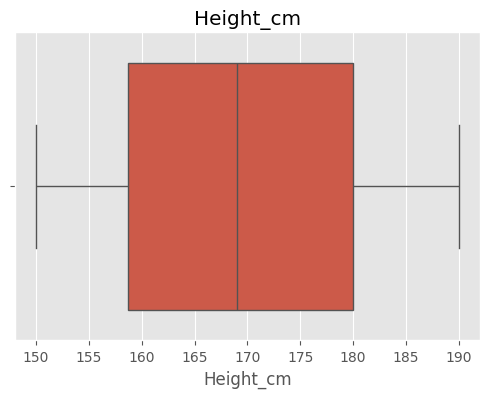

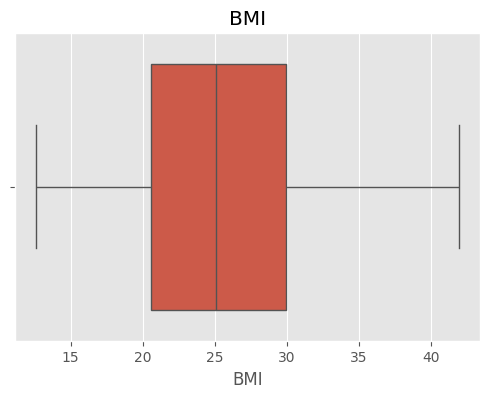

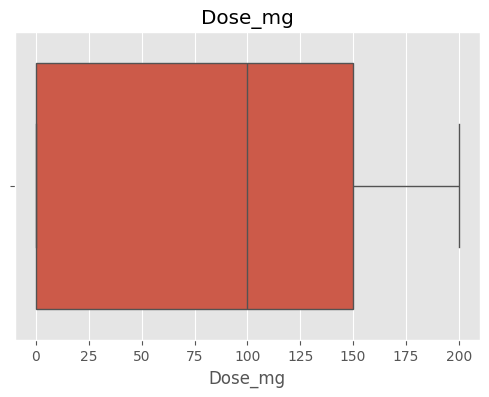

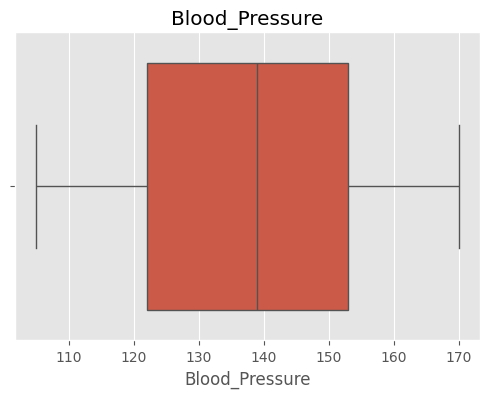

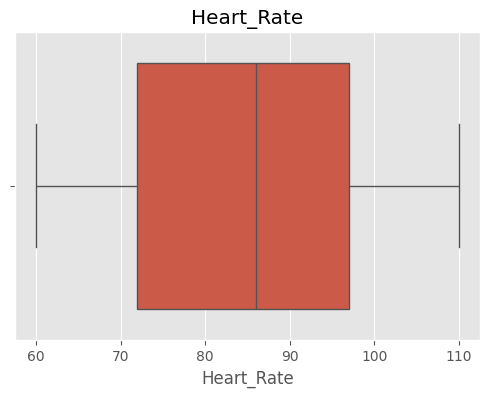

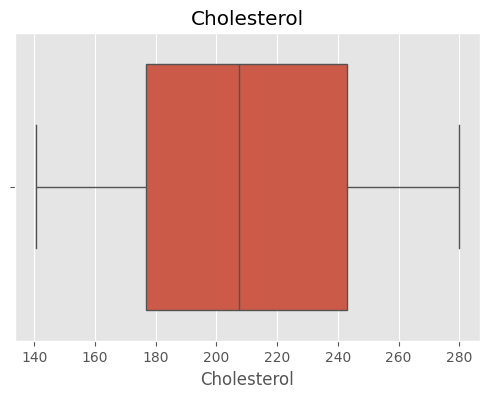

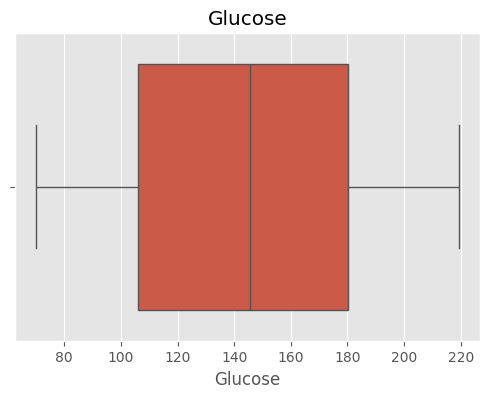

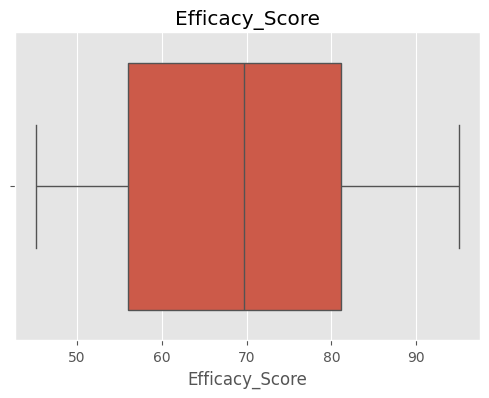

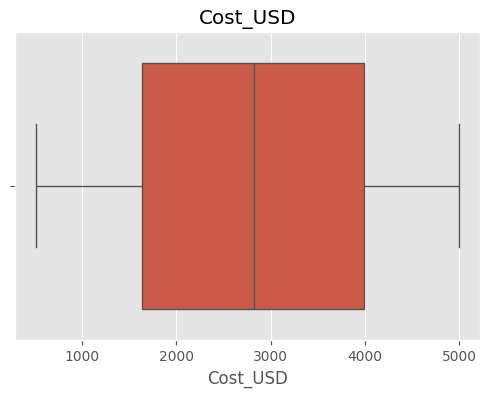

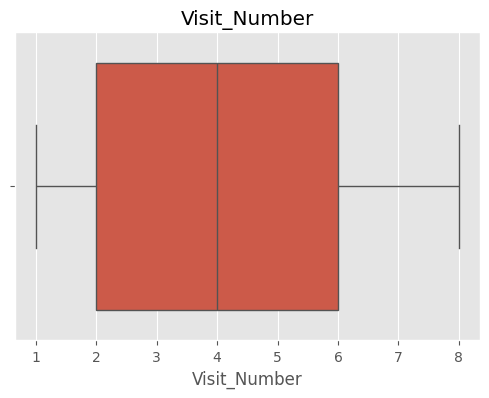

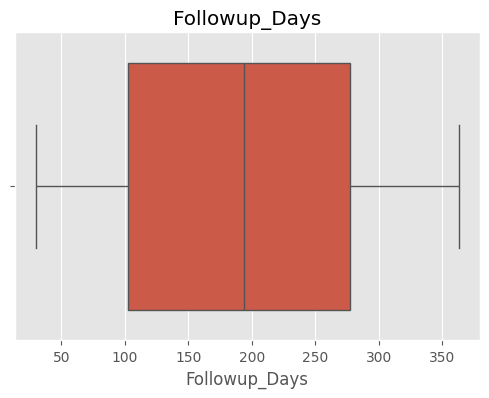

In [12]:
# 2. Boxplots (Outlier Detection)

# Patient Dataset
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


numeric_columns = patient_df.select_dtypes(include=np.number).columns

for column in numeric_columns:

    plt.figure(figsize=(6,4))

    sns.boxplot(x=patient_df[column])

    plt.title(column)

    plt.show()

# Treatment Dataset

numeric_columns = treatment_df.select_dtypes(include=np.number).columns

for column in numeric_columns:

    plt.figure(figsize=(6,4))

    sns.boxplot(x=treatment_df[column])

    plt.title(column)

    plt.show()

    # Hospital Dataset

    numeric_columns = hospital_df.select_dtypes(include=np.number).columns

for column in numeric_columns:

    plt.figure(figsize=(6,4))

    sns.boxplot(x=hospital_df[column])

    plt.title(column)

    plt.show()

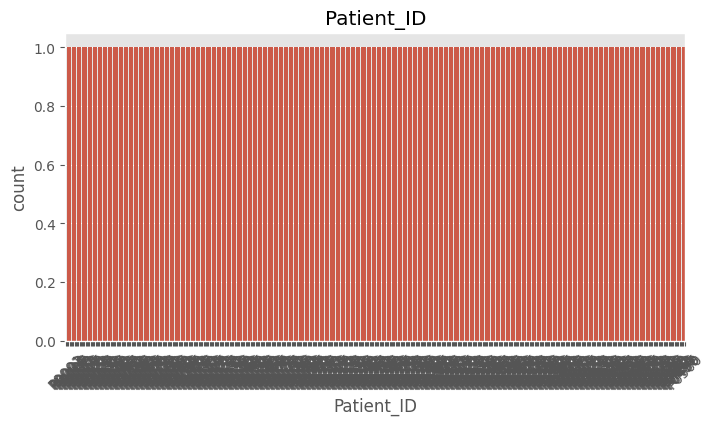

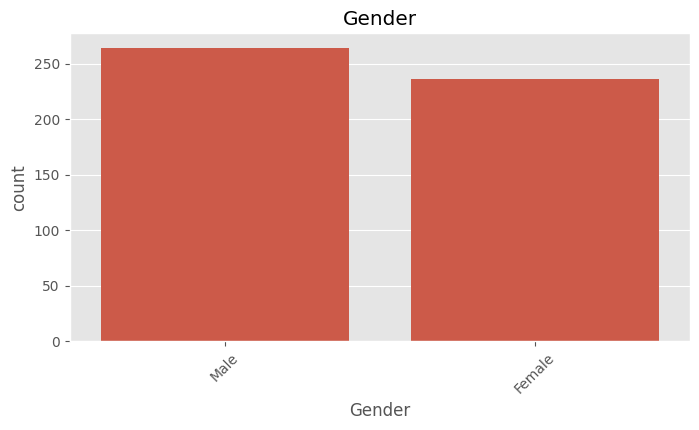

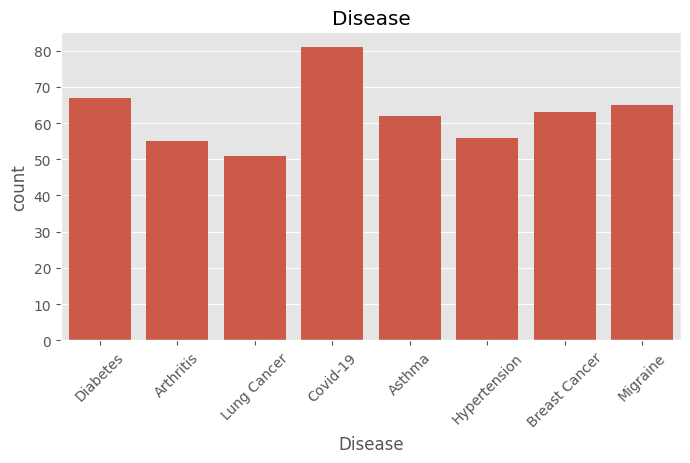

In [35]:
# 3. Count Plot for Categorical Variables

# Patient Dataset

categorical_columns = patient_df.select_dtypes(include="object").columns

for column in categorical_columns:

    plt.figure(figsize=(8,4))

    sns.countplot(data=patient_df, x=column)

    plt.xticks(rotation=45)

    plt.title(column)

    plt.show()


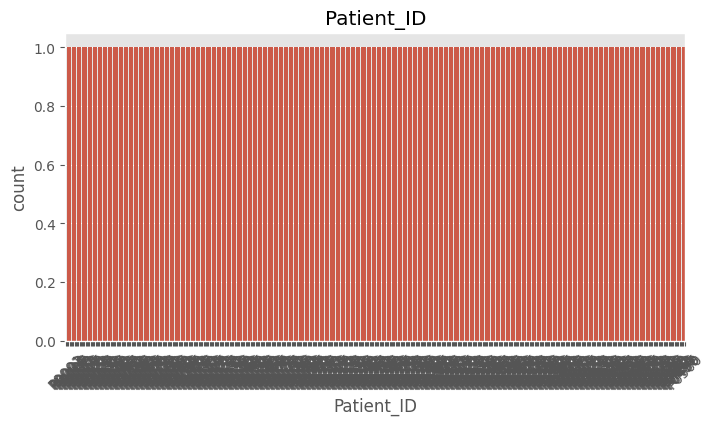

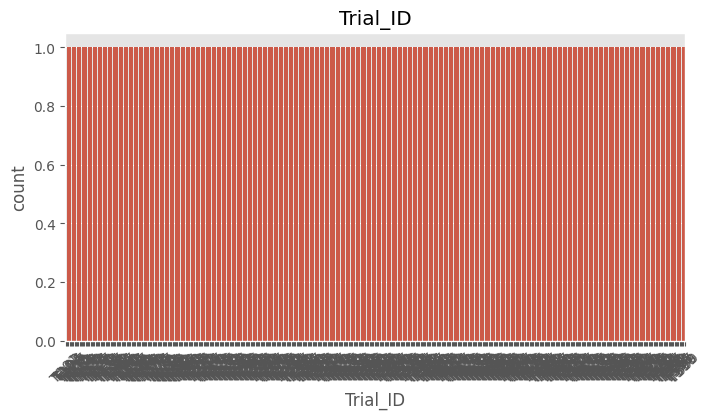

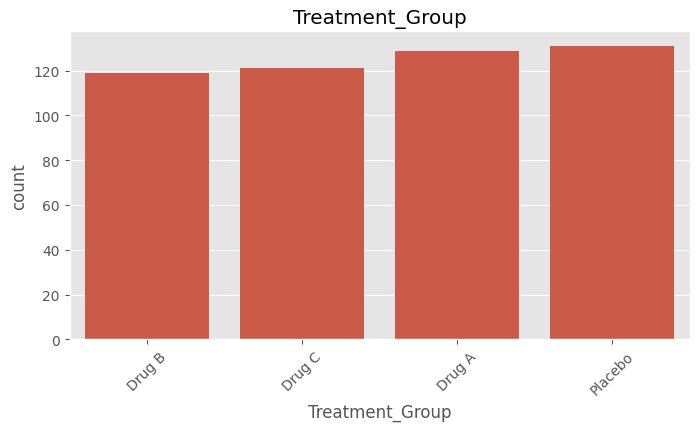

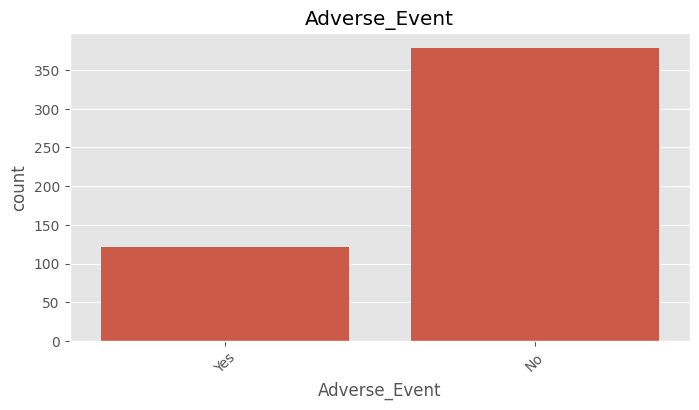

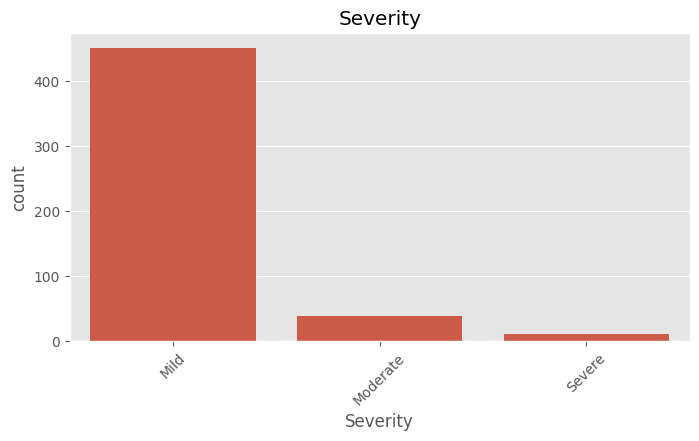

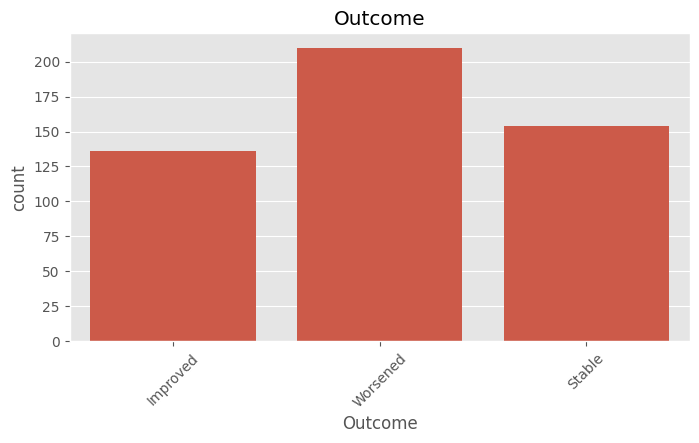

In [34]:
# Treatment Dataset

categorical_columns = treatment_df.select_dtypes(include="object").columns

for column in categorical_columns:

    plt.figure(figsize=(8,4))

    sns.countplot(data=treatment_df, x=column)

    plt.xticks(rotation=45)

    plt.title(column)

    plt.show()

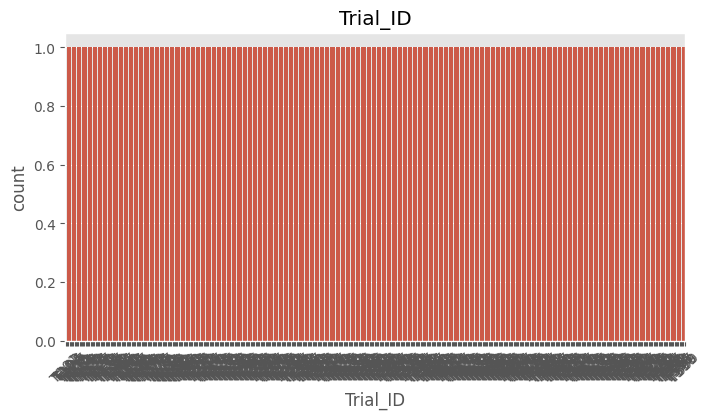

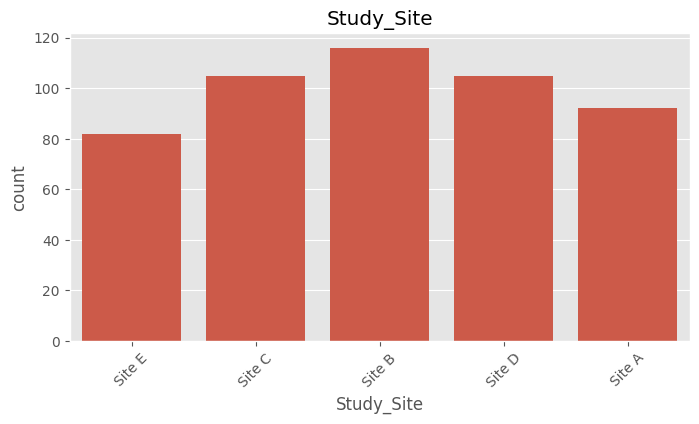

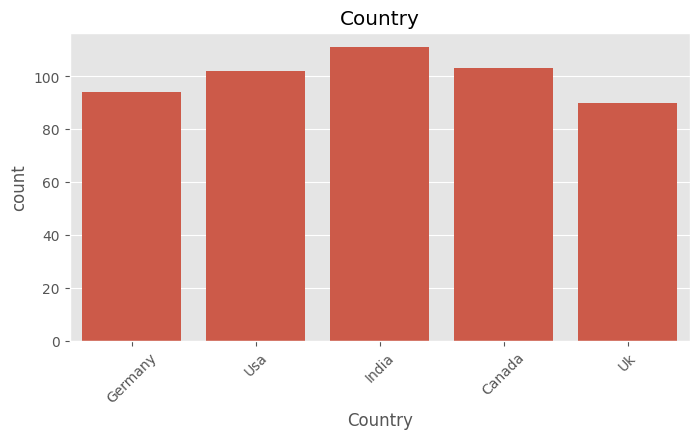

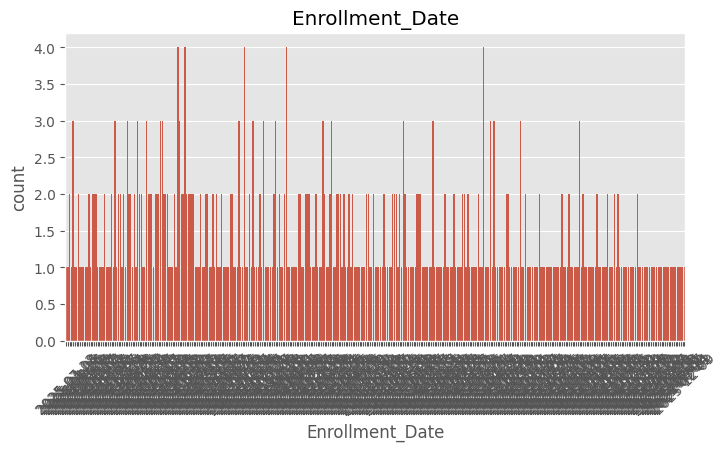

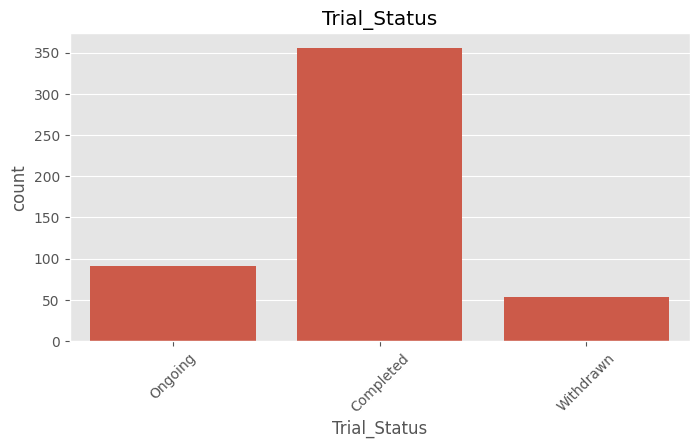

In [37]:
# Hospital Dataset

categorical_columns = hospital_df.select_dtypes(include="object").columns

for column in categorical_columns:

    plt.figure(figsize=(8,4))

    sns.countplot(data=hospital_df, x=column)

    plt.xticks(rotation=45)

    plt.title(column)

    plt.show()

### 2. BIVARIATE ANALYSIS

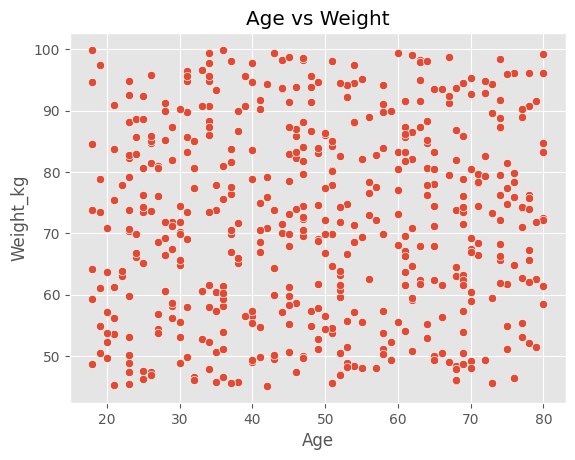

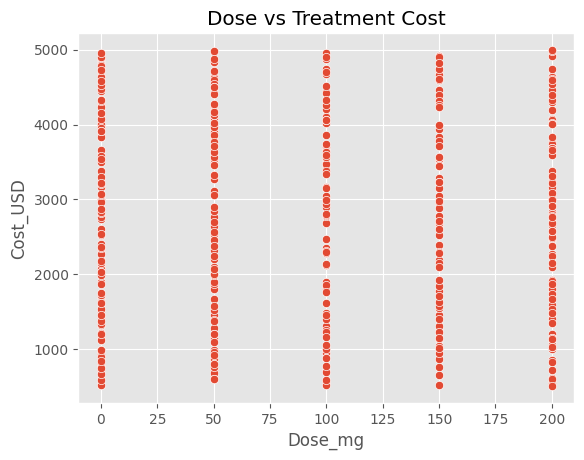

In [18]:
# 1. Scatter Plot (Numeric vs Numeric)

# Patient Dataset

sns.scatterplot(
    data=patient_df,
    x="Age",
    y="Weight_kg"
)

plt.title("Age vs Weight")
plt.show()

# Treatment Dataset

sns.scatterplot(
    data=treatment_df,
    x="Dose_mg",
    y="Cost_USD"
)

plt.title("Dose vs Treatment Cost")
plt.show()



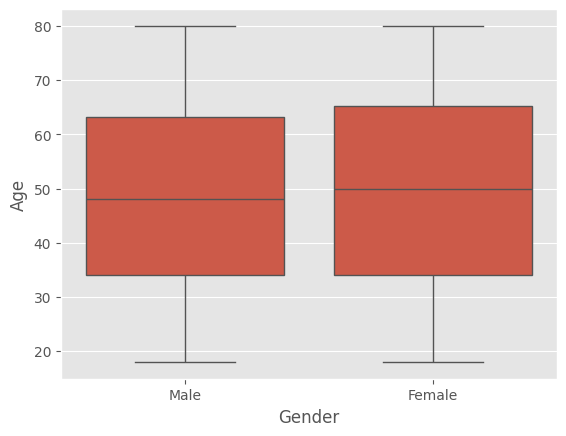

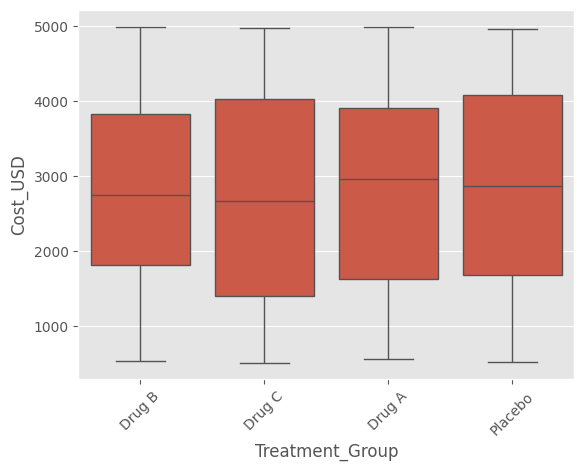

In [21]:
# 2. Boxplot (Categorical vs Numeric)

# Patient Dataset

sns.boxplot(
    data=patient_df,
    x="Gender",
    y="Age"
)

plt.show()

# Treatment Dataset

sns.boxplot(
    data=treatment_df,
    x="Treatment_Group",
    y="Cost_USD"
)

plt.xticks(rotation=45)

plt.show()

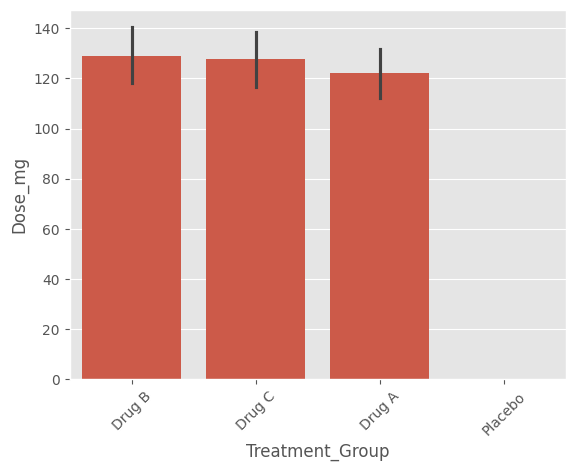

In [23]:
# 3. Bar Plot

sns.barplot(
    data=treatment_df,
    x="Treatment_Group",
    y="Dose_mg"
)

plt.xticks(rotation=45)

plt.show()

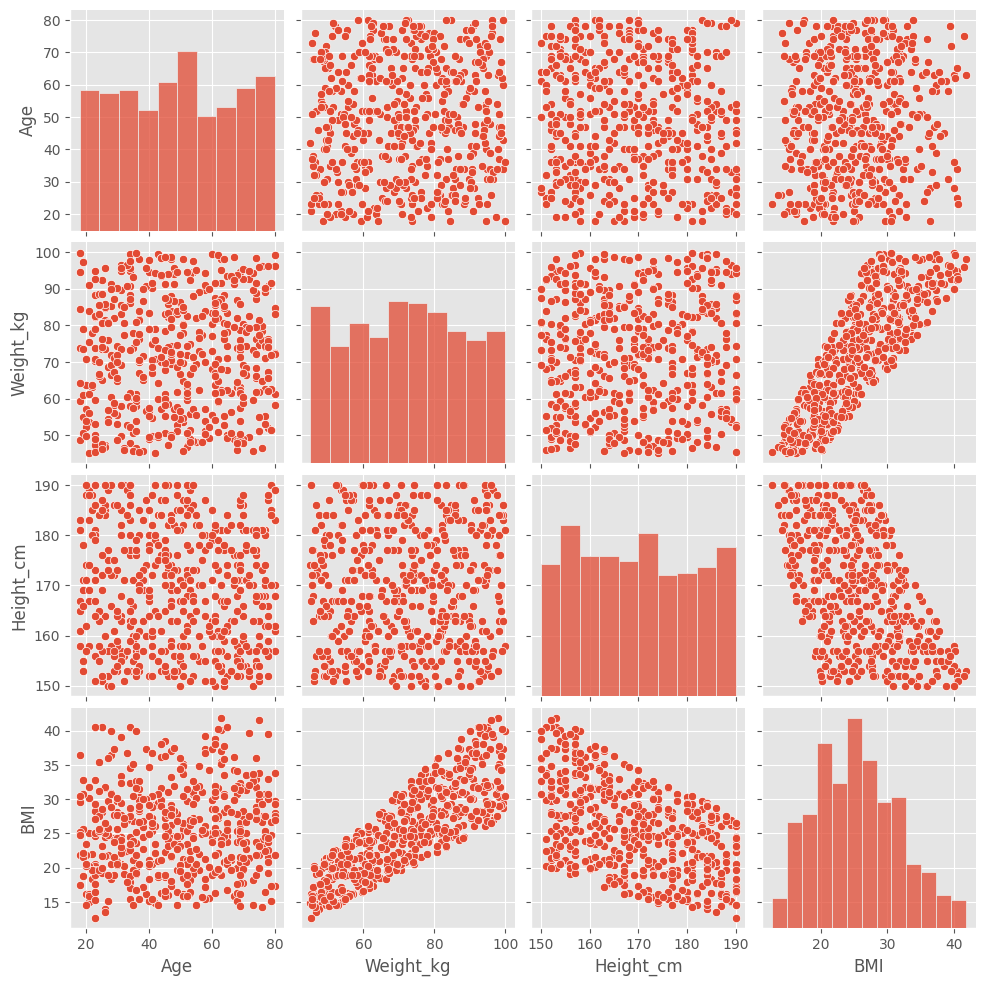

In [31]:
# 4. Pair Plot

# Patient Dataset

sns.pairplot(patient_df.select_dtypes(include=np.number))

plt.show()



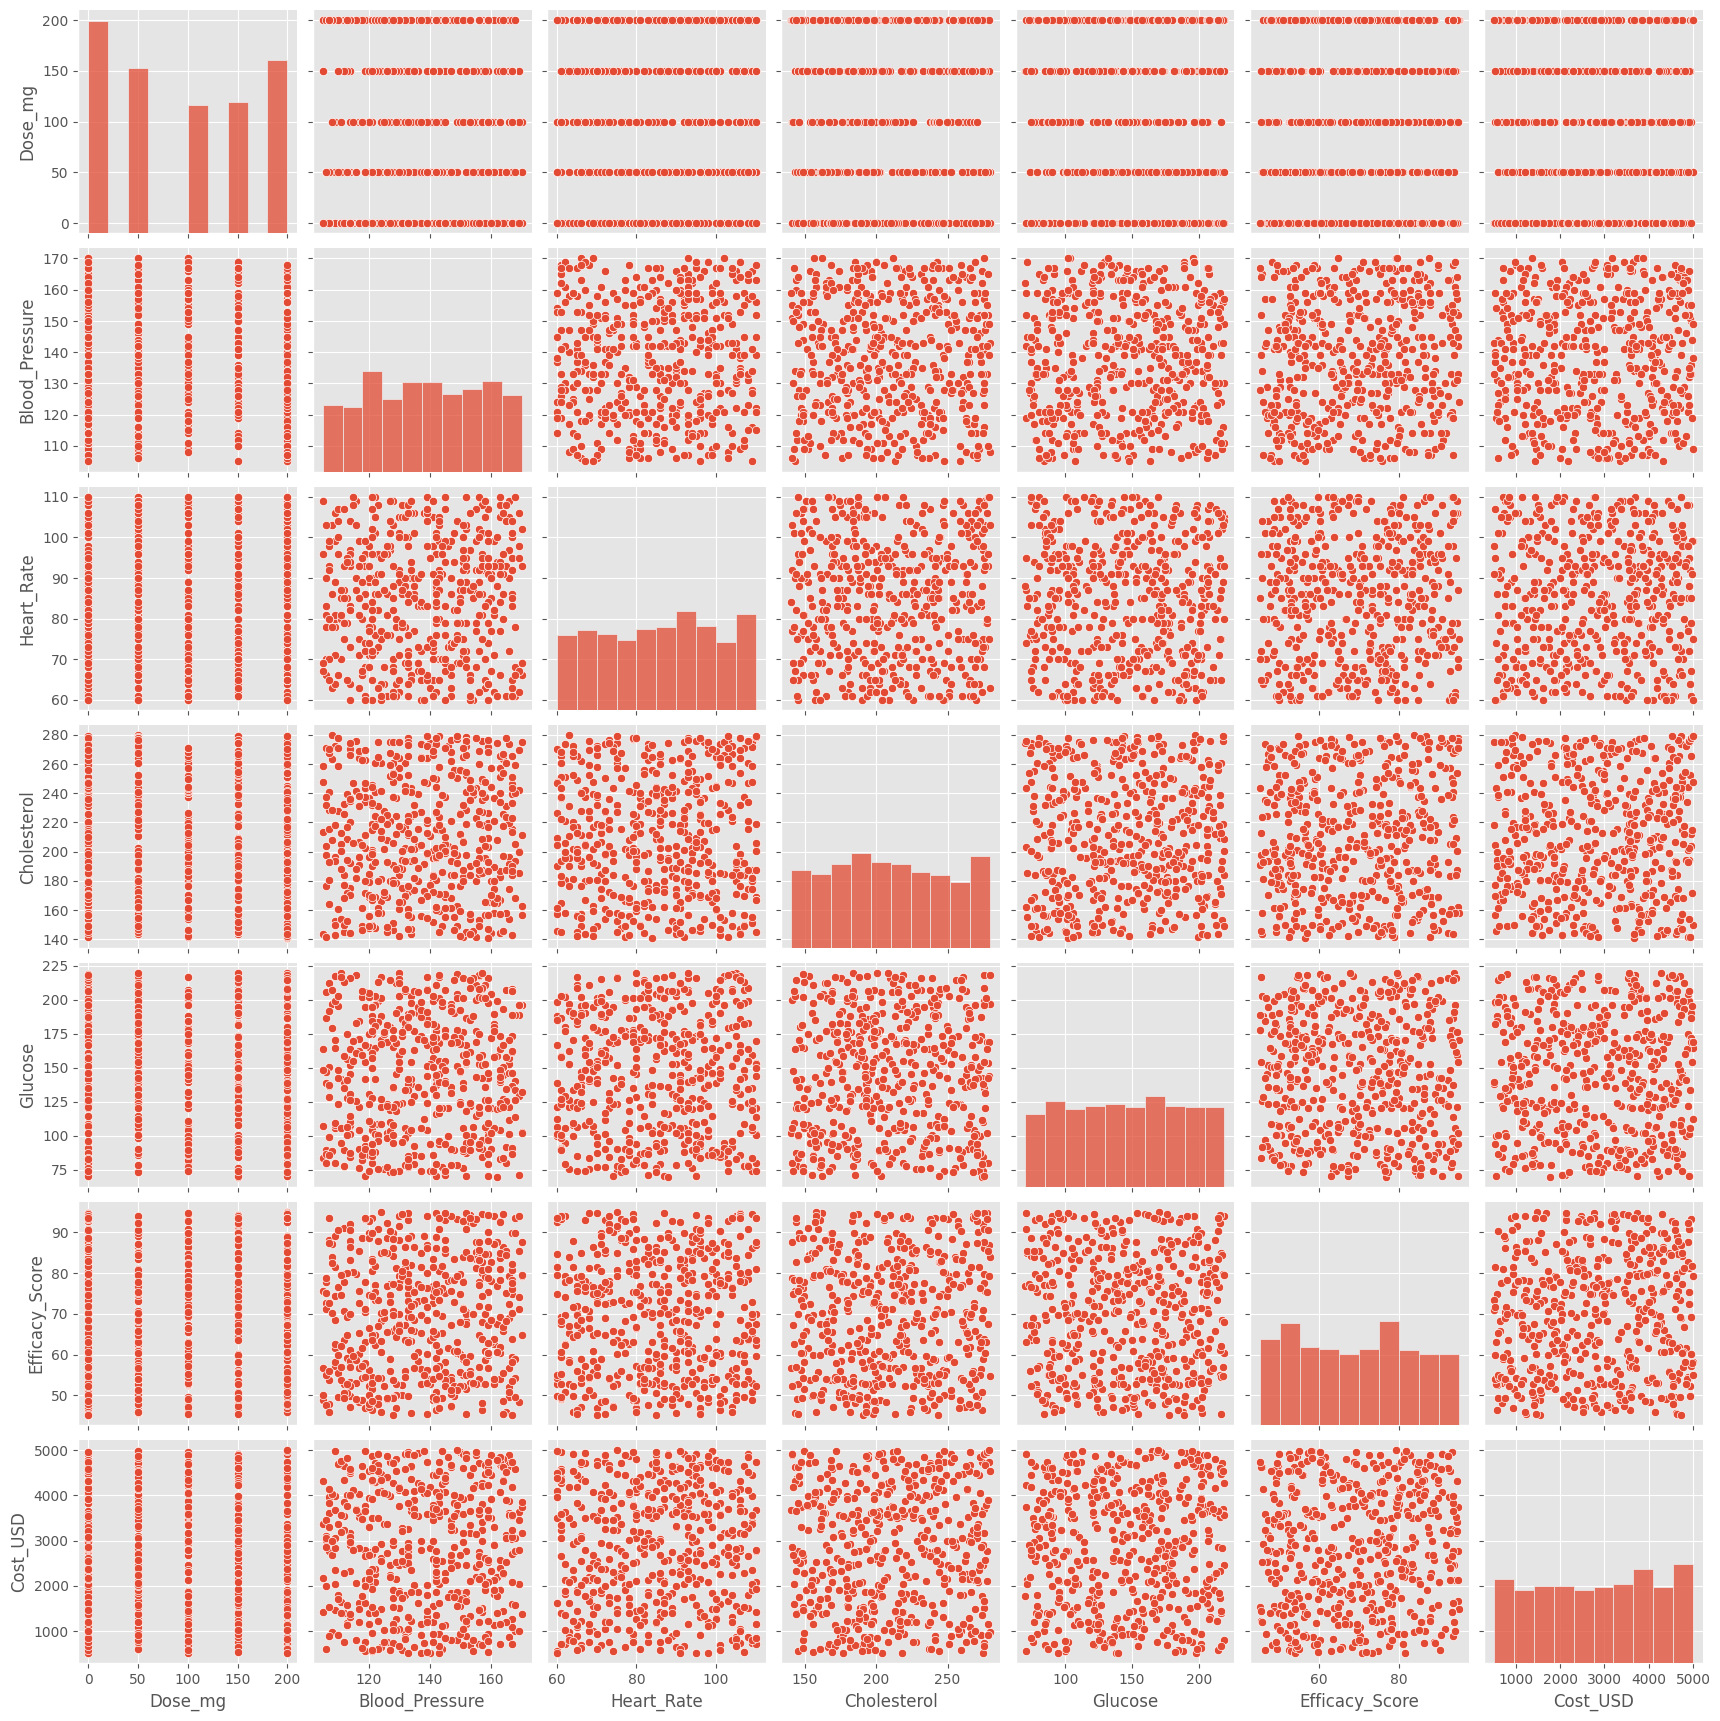

In [32]:
# Treatment Dataset

sns.pairplot(treatment_df.select_dtypes(include=np.number))

plt.show()

# CORRELATION MATRIX

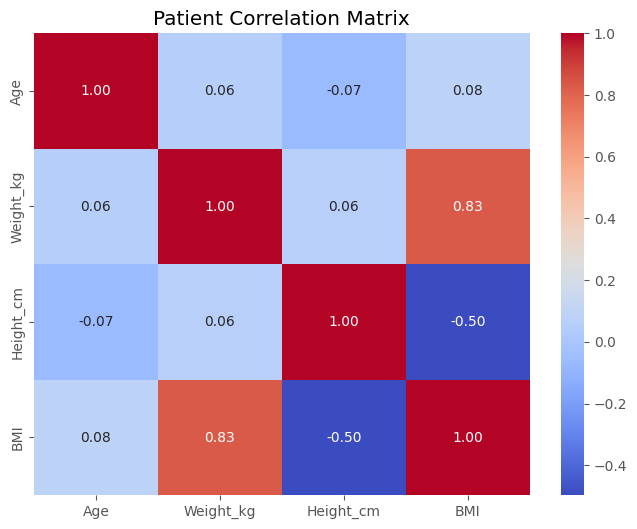

In [26]:
# Patient Dataset

plt.figure(figsize=(8,6))

corr = patient_df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Patient Correlation Matrix")

plt.show()

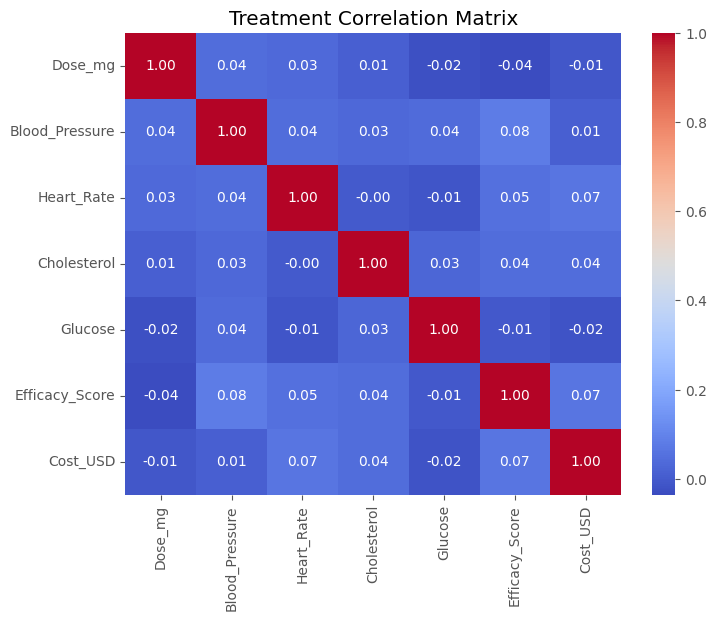

In [27]:
# Treatment Dataset

plt.figure(figsize=(8,6))

corr = treatment_df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Treatment Correlation Matrix")

plt.show()

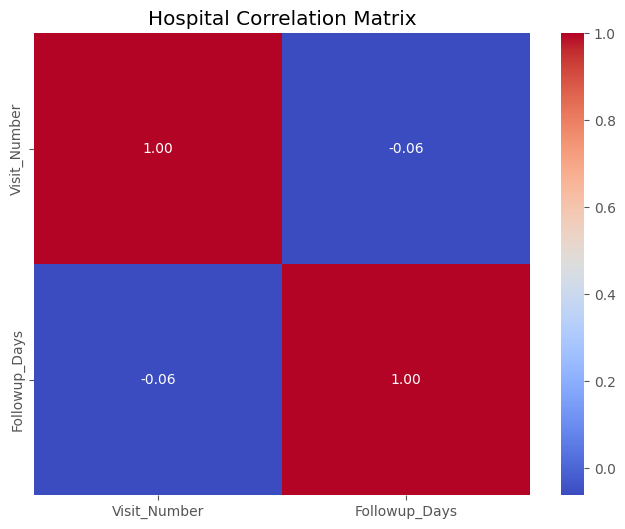

In [28]:
# Hospital Dataset

plt.figure(figsize=(8,6))

corr = hospital_df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Hospital Correlation Matrix")

plt.show()

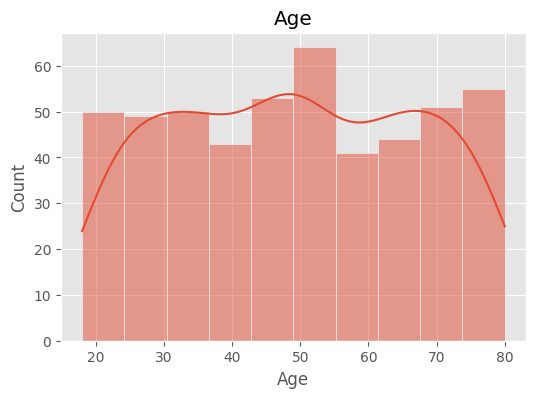

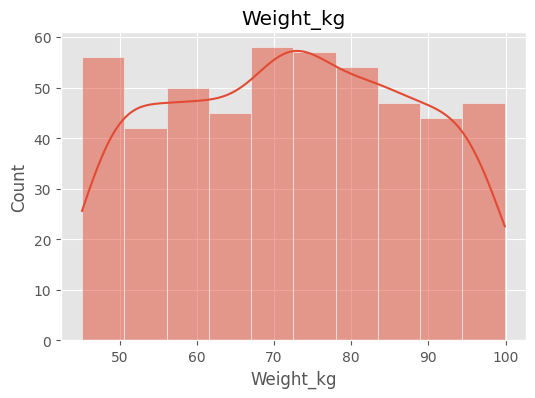

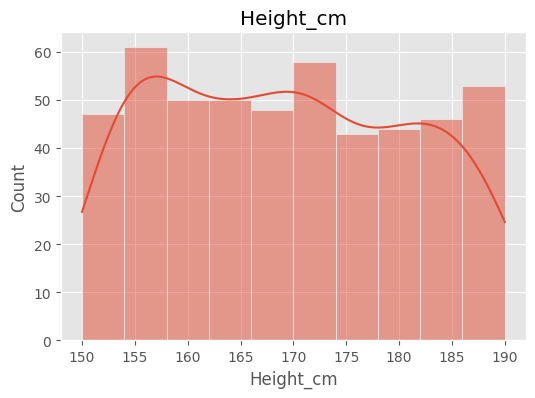

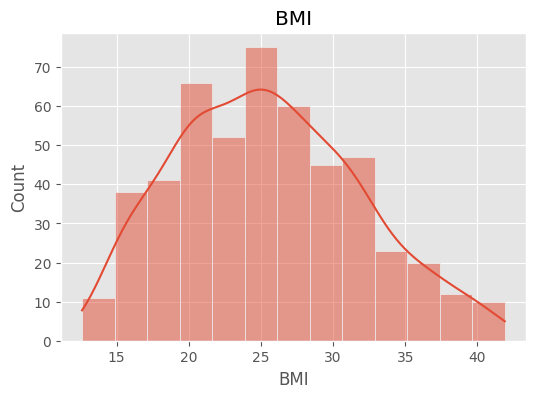

In [30]:
# Distribution Plot

numeric_columns = patient_df.select_dtypes(include=np.number).columns

for column in numeric_columns:

    plt.figure(figsize=(6,4))

    sns.histplot(
        patient_df[column],
        kde=True
    )

    plt.title(column)

    plt.show()

#LABEL ENCODING

In [39]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Patient Dataset

patient_label = patient_df.copy()

label_encoder = LabelEncoder()

for column in patient_label.select_dtypes(include="object").columns:

    if patient_label[column].nunique() == 2:

        patient_label[column] = label_encoder.fit_transform(patient_label[column])

print(patient_label.head())

  Patient_ID  Age  Gender  Weight_kg  Height_cm   BMI      Disease
0      P0001   58       1       51.1        167  18.3     Diabetes
1      P0002   44       1       57.1        187  16.3    Arthritis
2      P0003   47       1       74.5        174  24.6  Lung Cancer
3      P0004   40       1       56.5        167  20.3    Arthritis
4      P0005   63       0       62.3        181  19.0     Covid-19


In [40]:
# Treatment Dataset

treatment_label = treatment_df.copy()

label_encoder = LabelEncoder()

for column in treatment_label.select_dtypes(include="object").columns:

    if treatment_label[column].nunique() == 2:

        treatment_label[column] = label_encoder.fit_transform(treatment_label[column])

print(treatment_label.head())

  Patient_ID Trial_ID Treatment_Group  Dose_mg  Blood_Pressure  Heart_Rate  \
0      P0001     T101          Drug B      100             134          92   
1      P0002     T102          Drug C       50             153          66   
2      P0003     T103          Drug A      150             134          66   
3      P0004     T104          Drug A      100             109          80   
4      P0005     T105         Placebo        0             133          68   

   Cholesterol  Glucose  Adverse_Event Severity  Efficacy_Score   Outcome  \
0        224.3    154.2              1     Mild            82.0  Improved   
1        190.3    121.6              0     Mild            53.0  Worsened   
2        193.2    138.0              0     Mild            75.9    Stable   
3        196.2     79.9              0     Mild            57.2  Worsened   
4        211.3     83.6              0     Mild            77.1    Stable   

   Cost_USD  
0   3655.96  
1    695.53  
2   1231.94  
3   3052.31 

In [41]:
# Hospital Dataset

hospital_label = hospital_df.copy()

label_encoder = LabelEncoder()

for column in hospital_label.select_dtypes(include="object").columns:

    if hospital_label[column].nunique() == 2:

        hospital_label[column] = label_encoder.fit_transform(hospital_label[column])

print(hospital_label.head())

  Trial_ID Study_Site  Country Enrollment_Date  Visit_Number  Followup_Days  \
0     T101     Site E  Germany      2025-07-12             2            141   
1     T102     Site C      Usa      2025-03-08             2             77   
2     T103     Site B    India      2025-01-05             5             70   
3     T104     Site C   Canada      2025-04-18             1            147   
4     T105     Site B      Usa      2024-05-26             7            215   

  Trial_Status  
0      Ongoing  
1    Completed  
2      Ongoing  
3    Withdrawn  
4    Completed  


# ONE-HOT ENCODING

In [42]:
# Patient Dataset

patient_onehot = pd.get_dummies(
    patient_label,
    columns=[
        col for col in patient_label.select_dtypes(include="object").columns
        if patient_label[col].nunique() > 2
    ],
    drop_first=True
)

print(patient_onehot.head())

   Age  Gender  Weight_kg  Height_cm   BMI  Patient_ID_P0002  \
0   58       1       51.1        167  18.3             False   
1   44       1       57.1        187  16.3              True   
2   47       1       74.5        174  24.6             False   
3   40       1       56.5        167  20.3             False   
4   63       0       62.3        181  19.0             False   

   Patient_ID_P0003  Patient_ID_P0004  Patient_ID_P0005  Patient_ID_P0006  \
0             False             False             False             False   
1             False             False             False             False   
2              True             False             False             False   
3             False              True             False             False   
4             False             False              True             False   

   ...  Patient_ID_P0498  Patient_ID_P0499  Patient_ID_P0500  Disease_Asthma  \
0  ...             False             False             False           F

In [43]:
# Treatment Dataset

treatment_onehot = pd.get_dummies(
    treatment_label,
    columns=[
        col for col in treatment_label.select_dtypes(include="object").columns
        if treatment_label[col].nunique() > 2
    ],
    drop_first=True
)

print(treatment_onehot.head())

   Dose_mg  Blood_Pressure  Heart_Rate  Cholesterol  Glucose  Adverse_Event  \
0      100             134          92        224.3    154.2              1   
1       50             153          66        190.3    121.6              0   
2      150             134          66        193.2    138.0              0   
3      100             109          80        196.2     79.9              0   
4        0             133          68        211.3     83.6              0   

   Efficacy_Score  Cost_USD  Patient_ID_P0002  Patient_ID_P0003  ...  \
0            82.0   3655.96             False             False  ...   
1            53.0    695.53              True             False  ...   
2            75.9   1231.94             False              True  ...   
3            57.2   3052.31             False             False  ...   
4            77.1    993.42             False             False  ...   

   Trial_ID_T598  Trial_ID_T599  Trial_ID_T600  Treatment_Group_Drug B  \
0          False  

In [44]:
# Hospital Dataset

hospital_onehot = pd.get_dummies(
    hospital_label,
    columns=[
        col for col in hospital_label.select_dtypes(include="object").columns
        if hospital_label[col].nunique() > 2
    ],
    drop_first=True
)

print(hospital_onehot.head())

   Visit_Number  Followup_Days  Trial_ID_T102  Trial_ID_T103  Trial_ID_T104  \
0             2            141          False          False          False   
1             2             77           True          False          False   
2             5             70          False           True          False   
3             1            147          False          False           True   
4             7            215          False          False          False   

   Trial_ID_T105  Trial_ID_T106  Trial_ID_T107  Trial_ID_T108  Trial_ID_T109  \
0          False          False          False          False          False   
1          False          False          False          False          False   
2          False          False          False          False          False   
3          False          False          False          False          False   
4           True          False          False          False          False   

   ...  Enrollment_Date_2025-12-14  Enrollme

In [45]:
patient_onehot.to_csv("Patient_Encoded.csv", index=False)

treatment_onehot.to_csv("Treatment_Encoded.csv", index=False)

hospital_onehot.to_csv("Hospital_Encoded.csv", index=False)

print("Encoding completed successfully!")

Encoding completed successfully!


# Statistical Analysis



In [46]:
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway
from scipy.stats import pearsonr
from scipy.stats import shapiro

In [47]:
# 1. T-Test

# Compare the mean age of Male and Female patients.

male = patient_df[patient_df["Gender"] == "Male"]["Age"]

female = patient_df[patient_df["Gender"] == "Female"]["Age"]

t_stat, p_value = ttest_ind(male, female)

print("T Statistic :", t_stat)
print("P Value :", p_value)

if p_value < 0.05:
    print("Significant Difference")
else:
    print("No Significant Difference")

T Statistic : -0.032408078808866196
P Value : 0.9741596043330973
No Significant Difference


In [48]:
# 2. Chi-Square Test

# Relationship between Gender and Disease.

contingency_table = pd.crosstab(
    patient_df["Gender"],
    patient_df["Disease"]
)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi Square :", chi2)
print("P Value :", p_value)
print("Degrees of Freedom :", dof)

if p_value < 0.05:
    print("Variables are Associated")
else:
    print("Variables are Independent")

Chi Square : 5.010262269079277
P Value : 0.658710808959392
Degrees of Freedom : 7
Variables are Independent


In [50]:
# 3. One-Way ANOVA

# Compare Treatment Cost among different Treatment Types.

groups = []

for treatment in treatment_df["Treatment_Group"].unique():

    groups.append(
        treatment_df[
            treatment_df["Treatment_Group"] == treatment
        ]["Cost_USD"]
    )

F_statistic, p_value = f_oneway(*groups)

print("F Statistic :", F_statistic)
print("P Value :", p_value)

if p_value < 0.05:
    print("At least one group mean is significantly different.")
else:
    print("No significant difference among group means.")

F Statistic : 0.21193886492029973
P Value : 0.8881323467190678
No significant difference among group means.
